# LOGO fold strategy — does "hold one use case out" generalize?

**Author:** SF — **Branch:** `folding-strategies` — **Scope:** modelling/CV-design notebook,
read-only against `data/processed/`, no files written back.

## Why this notebook exists

`wf_fold_pca_test.ipynb` and `sf_eda_v2.ipynb` §14 both held out **one** use case
(`tech_forecasting`) and found every baseline collapses from ~0.80 in-distribution ROC-AUC
to ~0.55 on it. That is the right question to ask — this product's real deployment scenario
is "a brand-new research question walks in with zero training rows" — but a single holdout
is one draw from six possible draws. `tech_forecasting` was chosen *because* it's the
smallest and most topically distinct use case, which means the 0.55 number could be telling
us either:

1. **the model doesn't transfer to a new domain, period** (a general finding), or
2. **the model transfers fine to a *similar* new domain and only fails on a topically distant
   one** (a much narrower, more actionable finding — it would mean the fix is a similarity
   guardrail before trusting the model on a new use case, not a fundamentally different
   modelling approach).

A single holdout cannot distinguish these two stories. **Leave-One-Use-Case-Out (LOGO)** —
rotating the holdout through all 6 use cases and looking at the *distribution* of held-out
scores, not one number — can. (§4 below resolves which of the two stories the data actually
supports — it isn't the one the single-holdout framing suggested.)

## What this notebook does

- Reuses `sf_eda_v2.ipynb` §13's exact three baseline candidates (`LogisticRegression`,
  `RandomForestClassifier`, `HistGradientBoostingClassifier`, plus the `DummyClassifier`
  floor) and its feature set (384-dim `embedding` + `citation_velocity`) unchanged — this is
  a fold-design comparison, not a new modelling attempt, so the model/feature side is held
  fixed on purpose.
- For each of the 6 use cases in turn: removes it entirely (`holdout`), trains on the other 5
  (`dev_pool`), and reports **both** an in-distribution reference score (a `StratifiedGroupKFold`
  grouped by first-author, computed *within* that rotation's dev pool — i.e. what the team
  would have believed about the model without holding anything out) **and** the true
  held-out score on the untouched 6th use case. The gap between those two numbers, repeated
  across all 6 rotations, is the headline result.
- Adds two checks the single-holdout version didn't have: a **cross-use-case duplicate-title
  leakage check** (flagged in `sf_eda_v2.ipynb` §6.2 as a real risk for any use-case-level
  split, never fixed), and a **bootstrap confidence interval** on each held-out AUC, since
  holdout sizes here are only 290–690 rows and a single point estimate at that scale is not
  enough to rank models by.

## How to read this notebook

Same convention as the EDA notebooks this builds on: a "Finding" cell after a table/chart is
either a **hard finding** (recompute the cell above it and you get the same number) or a
**judgement call** (an interpretation that needs product context and could reasonably be
argued differently).

**Running this notebook:** open it from inside `notebooks/modelling/` (so the relative data
path resolves), then Run All. Nothing is written to `data/`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, recall_score, fbeta_score
from sklearn.base import clone

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

DATA_PATH = "../../data/processed/papers_combined.parquet"
df = pd.read_parquet(DATA_PATH)
print(f"Loaded {df.shape[0]:,} rows, {df.shape[1]} columns from {DATA_PATH}")


Loaded 2,873 rows, 50 columns from ../../data/processed/papers_combined.parquet


In [2]:
# Feature engineering — identical to sf_eda_v2.ipynb §7.1 / §12, unchanged on purpose
df["exported_year"] = pd.to_datetime(df["exported_at"]).dt.year
df["paper_age"] = (df["exported_year"] - df["year"]).clip(lower=0)
df["citation_velocity"] = df["citation_count"] / (df["paper_age"].astype("float") + 1)

def first_author(s):
    if pd.isna(s) or str(s).strip() == "":
        return np.nan
    return str(s).split(",")[0].strip().lower()

df["first_author"] = df["authors"].apply(first_author)
missing_author = df["first_author"].isna()
df.loc[missing_author, "first_author"] = "no_author_" + df.index[missing_author].astype(str)

reviewed_bin = df[df["triage_label"].isin(["positive", "negative"])].copy()
USE_CASES = sorted(reviewed_bin["use_case_key"].unique().tolist())
print(f"{len(reviewed_bin)} reviewed rows (positive/negative only) across {len(USE_CASES)} use cases:")
reviewed_bin["use_case_key"].value_counts().reindex(USE_CASES)


1852 reviewed rows (positive/negative only) across 6 use cases:


use_case_key
carbon_capture      297
cement_binders      262
ner                 312
soil_microbiome     357
solar_leo           360
tech_forecasting    264
Name: count, dtype: int64

## 1. Cross-use-case duplicate-title leakage check

`sf_eda_v2.ipynb` §6.2 flagged that a small number of papers appear under more than one
`use_case_key` (the same real paper retrieved by two different research questions) and warned
this is "a real leakage risk for any train/test split." It matters more here than it did for
the original author-grouped CV: LOGO's entire premise is that the held-out use case is
*unseen*, so if any of its papers also sit in the training use cases, that premise is
partially false for those specific rows.


In [3]:
title_norm = df["title"].str.lower().str.strip().str.replace(r"\s+", " ", regex=True)

dup_mask = title_norm.duplicated(keep=False) & title_norm.notna()
cross_uc_counts = (
    df.loc[dup_mask]
    .assign(title_norm=title_norm[dup_mask])
    .groupby("title_norm")["use_case_key"]
    .nunique()
)
cross_uc_titles = cross_uc_counts[cross_uc_counts > 1]
print(f"{len(cross_uc_titles)} distinct titles appear under more than one use_case_key "
      f"(out of {df.shape[0]:,} rows total).")

if len(cross_uc_titles):
    display(
        df.loc[title_norm.isin(cross_uc_titles.index), ["paper_id", "use_case_key", "title"]]
        .sort_values("title")
    )

# Per-rotation view: of each candidate holdout use case's titles, how many also appear
# in the other 5 use cases (i.e. would leak into that rotation's dev_pool)?
leak_rows = []
for holdout_uc in USE_CASES:
    dev_titles = set(title_norm[df["use_case_key"] != holdout_uc].dropna())
    holdout_titles = title_norm[df["use_case_key"] == holdout_uc]
    n_leak = holdout_titles.isin(dev_titles).sum()
    leak_rows.append({
        "holdout_use_case": holdout_uc,
        "n_holdout_rows": int((df["use_case_key"] == holdout_uc).sum()),
        "n_titles_also_in_dev_pool": int(n_leak),
    })

leak_check = pd.DataFrame(leak_rows).set_index("holdout_use_case")
leak_check


5 distinct titles appear under more than one use_case_key (out of 2,873 rows total).


,paper_id,use_case_key,title
1933,ner__2939,ner,Joint entity-relation extraction: A key techni...
2389,tech_forecasting__3205,tech_forecasting,Joint entity-relation extraction: A key techni...
1946,ner__2941,ner,Mpathrp: A Knowledge Graph Relationship Predic...
2232,tech_forecasting__1099,tech_forecasting,Mpathrp: A Knowledge Graph Relationship Predic...
264,carbon_capture__3526,carbon_capture,Recent advances in carbon capture storage and ...
1367,cement_binders__332,cement_binders,Recent advances in carbon capture storage and ...
2041,ner__2951,ner,Tackling Sparse Facts for Temporal Knowledge G...
2339,tech_forecasting__3148,tech_forecasting,Tackling Sparse Facts for Temporal Knowledge G...
2108,ner__2959,ner,Temporal knowledge graph completion based on t...
2294,tech_forecasting__3183,tech_forecasting,Temporal knowledge graph completion based on t...


,n_holdout_rows,n_titles_also_in_dev_pool
holdout_use_case,,
carbon_capture,323,1
cement_binders,690,1
ner,541,4
soil_microbiome,602,0
solar_leo,427,0
tech_forecasting,290,4


**Hard finding.** 5 distinct titles cross a use-case boundary (out of 2,873 rows total) — 4 of
them tie `ner` to `tech_forecasting` (all knowledge-graph/entity-extraction papers relevant to
both research questions), 1 ties `carbon_capture` to `cement_binders`. Only 4 of the 6
rotations are affected at all: `ner` and `tech_forecasting` each pick up 4 leaked rows (≈1.3–1.5%
of a 312/264-row holdout), `carbon_capture` and `cement_binders` each pick up exactly 1,
`soil_microbiome` and `solar_leo` are clean (0). At this scale the leakage is real and worth
fixing in `combine_use_cases.ipynb`, but it is far too small (≤4 rows) to be driving the
AUC collapse seen in §4 below — don't use it to dismiss that finding.


## 2. Shared building blocks — same candidates and metrics as `sf_eda_v2.ipynb` §13

The model list, the ranking metrics (`recall_at_Xpct` / `wss_at_95`, this repo's own
citation-screening convention from `scripts/embedding_utils.py`), and the
`StandardScaler`-fit-on-train-only discipline are copied verbatim from §13/§14 of
`sf_eda_v2.ipynb` — nothing about the models or features changes here, only the fold
structure around them.

Two additions:
- `bootstrap_auc_ci` puts a confidence interval on each held-out AUC by resampling the
  (already-computed) held-out predictions, not by refitting anything — cheap, and necessary
  at 290–690 rows per holdout where a bare point estimate invites over-reading a 0.02–0.05
  gap between models as a real ranking.
- **Recall and F2** (`beta=2`, so recall counts 4x as much as precision) at the classifier's
  default 0.5 probability threshold, alongside ROC-AUC — per
  `reports/wf_ensemble_report.md` §2's own recommendation ("F2 if a hard threshold decision
  is ever needed — recall weighted over precision"), since the product cost of missing a
  relevant paper (a false negative a human never sees to correct) is higher than the cost of
  one extra paper to screen (a false positive). Reported at **three stages** per model per
  rotation — **train** (fit on `dev_pool`, scored on that same `dev_pool` — the optimistic,
  in-sample number), **validation** (the inner `StratifiedGroupKFold` estimate — what CV
  alone would have reported), and **holdout** (the true unseen-use-case score) — so the
  overfitting gap (train → validation) and the domain-shift gap (validation → holdout) can be
  told apart instead of collapsed into one number. §3.2 visualizes this directly.


In [4]:
def build_candidates():
    return {
        "DummyClassifier (floor)": DummyClassifier(strategy="most_frequent"),
        "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced"),
        "RandomForestClassifier": RandomForestClassifier(
            n_estimators=200, random_state=0, class_weight="balanced", n_jobs=-1
        ),
        "HistGradientBoostingClassifier": HistGradientBoostingClassifier(random_state=0),
    }

def ranking_metrics(y_true, scores, fractions=(0.10, 0.20), wss_target_recall=0.95):
    """recall_at_Xpct / wss_at_95 - identical definition to sf_eda_v2.ipynb §13 /
    scripts/embedding_utils.py's retrieval_ranking_metrics."""
    n = len(y_true)
    n_pos = int(y_true.sum())
    order = np.argsort(-scores)
    cum_pos = np.cumsum(y_true[order])
    out = {}
    for f in fractions:
        k = max(1, int(round(f * n)))
        out[f"recall_at_{int(f * 100)}pct"] = float(cum_pos[k - 1] / n_pos)
    target_count = int(np.ceil(wss_target_recall * n_pos))
    cutoff_idx = int(np.searchsorted(cum_pos, target_count, side="left"))
    screened = cutoff_idx + 1
    out["wss_at_95"] = float((n - screened) / n - (1 - wss_target_recall))
    return out

def bootstrap_auc_ci(y_true, scores, n_boot=1000, ci=0.95, random_state=0):
    """Percentile bootstrap CI on ROC-AUC, resampling rows of the already-computed
    held-out predictions (no refitting) - cheap enough to run for every rotation/model."""
    rng = np.random.RandomState(random_state)
    n = len(y_true)
    boot_aucs = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        boot_aucs.append(roc_auc_score(y_true[idx], scores[idx]))
    lo, hi = np.percentile(boot_aucs, [2.5, 97.5])
    return float(lo), float(hi), len(boot_aucs)


## 3. Leave-One-Use-Case-Out (LOGO) rotation

For each of the 6 use cases in turn:

- **Outer split (the generalization test):** remove that use case entirely -> `holdout`.
  Everything else -> `dev_pool`. The scaler is fit on `dev_pool` only; `holdout` is
  transformed with it, never used to fit anything.
- **Inner loop (the in-distribution reference):** a fresh `StratifiedGroupKFold(n_splits=5)`
  grouped by first-author, run *within this rotation's* `dev_pool` — i.e. exactly the fold
  scheme `sf_eda_v2.ipynb` §13 already validated (shuffled-label sanity check, no author
  split across folds), just recomputed on 5 use cases instead of 6. This is the number the
  team would have reported as "cross-validated performance" if this particular use case had
  never been held out — it is the counterfactual the outer holdout score gets compared against.
- Each of the 3 real candidates (plus the `DummyClassifier` floor) is scored both ways.

6 use cases x 4 candidates = 24 rows below.


In [5]:
logo_rows = []

for holdout_uc in USE_CASES:
    dev_pool = reviewed_bin[reviewed_bin["use_case_key"] != holdout_uc].copy()
    holdout = reviewed_bin[reviewed_bin["use_case_key"] == holdout_uc].copy()

    X_dev = np.hstack([
        np.vstack(dev_pool["embedding"].to_numpy()),
        dev_pool[["citation_velocity"]].fillna(0.0).to_numpy(),
    ])
    X_holdout = np.hstack([
        np.vstack(holdout["embedding"].to_numpy()),
        holdout[["citation_velocity"]].fillna(0.0).to_numpy(),
    ])
    y_dev = (dev_pool["triage_label"].to_numpy() == "positive").astype(int)
    y_holdout = (holdout["triage_label"].to_numpy() == "positive").astype(int)
    groups_dev = dev_pool["first_author"].to_numpy()

    inner_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)
    inner_folds = list(inner_cv.split(X_dev, y_dev, groups_dev))

    scaler = StandardScaler().fit(X_dev)
    X_dev_s = scaler.transform(X_dev)
    X_holdout_s = scaler.transform(X_holdout)

    for name, clf in build_candidates().items():
        # inner loop: VALIDATION stage - out-of-fold score on this rotation's dev_pool,
        # exactly the fold scheme sf_eda_v2.ipynb §13 already validated
        val_aucs, val_recalls, val_f2s = [], [], []
        for tr_idx, te_idx in inner_folds:
            inner_scaler = StandardScaler().fit(X_dev[tr_idx])
            clf_inner = clone(clf)
            Xtr_s, Xte_s = inner_scaler.transform(X_dev[tr_idx]), inner_scaler.transform(X_dev[te_idx])
            clf_inner.fit(Xtr_s, y_dev[tr_idx])
            pos_col_inner = list(clf_inner.classes_).index(1)

            proba_te = clf_inner.predict_proba(Xte_s)[:, pos_col_inner]
            pred_te = clf_inner.predict(Xte_s)
            val_aucs.append(roc_auc_score(y_dev[te_idx], proba_te))
            val_recalls.append(recall_score(y_dev[te_idx], pred_te, zero_division=0))
            val_f2s.append(fbeta_score(y_dev[te_idx], pred_te, beta=2, zero_division=0))

        in_distribution_auc = float(np.mean(val_aucs))  # kept as-is: this is the VALIDATION stage

        # TRAIN stage: the model actually used for the holdout check below, scored on its
        # own training data (dev_pool) - the optimistic, in-sample number. Same fitted
        # model as the holdout evaluation, not a separate refit, so train->holdout below is
        # a fair before/after comparison of the one model that would actually get shipped.
        clf.fit(X_dev_s, y_dev)
        pos_col = list(clf.classes_).index(1)
        train_scores_full = clf.predict_proba(X_dev_s)[:, pos_col]
        train_pred_full = clf.predict(X_dev_s)
        train_auc_full = roc_auc_score(y_dev, train_scores_full)
        train_recall_full = recall_score(y_dev, train_pred_full, zero_division=0)
        train_f2_full = fbeta_score(y_dev, train_pred_full, beta=2, zero_division=0)

        # HOLDOUT stage: the truly unseen use case
        scores_holdout = clf.predict_proba(X_holdout_s)[:, pos_col]
        pred_holdout = clf.predict(X_holdout_s)

        holdout_auc = roc_auc_score(y_holdout, scores_holdout)
        holdout_ap = average_precision_score(y_holdout, scores_holdout)
        holdout_recall = recall_score(y_holdout, pred_holdout, zero_division=0)
        holdout_f2 = fbeta_score(y_holdout, pred_holdout, beta=2, zero_division=0)
        rm = ranking_metrics(y_holdout, scores_holdout)
        ci_lo, ci_hi, n_boot_ok = bootstrap_auc_ci(y_holdout, scores_holdout)

        logo_rows.append({
            "holdout_use_case": holdout_uc,
            "model": name,
            "n_dev": len(y_dev),
            "n_holdout": len(y_holdout),
            "holdout_pos_rate": round(float(y_holdout.mean()), 3),
            # train stage: fitted model scored on its own training data (dev_pool)
            "train_auc": round(train_auc_full, 3),
            "train_recall": round(float(train_recall_full), 3),
            "train_f2": round(float(train_f2_full), 3),
            # validation stage: inner StratifiedGroupKFold on dev_pool (existing column name kept)
            "in_distribution_auc": round(in_distribution_auc, 3),
            "in_distribution_recall": round(float(np.mean(val_recalls)), 3),
            "in_distribution_f2": round(float(np.mean(val_f2s)), 3),
            # holdout stage: the truly unseen use case
            "holdout_auc": round(float(holdout_auc), 3),
            "holdout_recall": round(float(holdout_recall), 3),
            "holdout_f2": round(float(holdout_f2), 3),
            "holdout_ap": round(float(holdout_ap), 3),
            # gaps: train->validation (overfitting) and validation->holdout (domain shift)
            "overfit_gap_auc": round(train_auc_full - in_distribution_auc, 3),
            "auc_gap": round(in_distribution_auc - float(holdout_auc), 3),
            **{k: round(v, 3) for k, v in rm.items()},
            "holdout_auc_ci_low": round(ci_lo, 3),
            "holdout_auc_ci_high": round(ci_hi, 3),
        })

logo_results = pd.DataFrame(logo_rows)
logo_results


,holdout_use_case,model,n_dev,n_holdout,holdout_pos_rate,train_auc,train_recall,train_f2,in_distribution_auc,in_distribution_recall,in_distribution_f2,holdout_auc,holdout_recall,holdout_f2,holdout_ap,overfit_gap_auc,auc_gap,recall_at_10pct,recall_at_20pct,wss_at_95,holdout_auc_ci_low,holdout_auc_ci_high
0,carbon_capture,DummyClassifier (floor),1555,297,0.495,0.500,1.000,0.879,0.500,1.000,0.879,0.500,1.000,0.831,0.495,0.000,0.000,0.156,0.293,-0.013,0.500,0.500
1,carbon_capture,LogisticRegression,1555,297,0.495,0.925,0.847,0.853,0.748,0.735,0.739,0.616,0.238,0.273,0.586,0.177,0.132,0.122,0.265,0.054,0.552,0.675
2,carbon_capture,RandomForestClassifier,1555,297,0.495,1.000,1.000,1.000,0.811,0.824,0.809,0.484,0.027,0.034,0.496,0.189,0.326,0.116,0.204,-0.003,0.424,0.550
3,carbon_capture,HistGradientBoostingClassifier,1555,297,0.495,1.000,1.000,1.000,0.811,0.854,0.831,0.521,0.088,0.106,0.529,0.189,0.290,0.102,0.211,-0.003,0.461,0.587
4,cement_binders,DummyClassifier (floor),1590,262,0.649,0.500,1.000,0.866,0.500,1.000,0.866,0.500,1.000,0.902,0.649,0.000,0.000,0.153,0.294,0.206,0.500,0.500
5,cement_binders,LogisticRegression,1590,262,0.649,0.915,0.839,0.844,0.747,0.709,0.715,0.642,0.612,0.633,0.718,0.168,0.105,0.094,0.218,0.072,0.567,0.716
6,cement_binders,RandomForestClassifier,1590,262,0.649,1.000,1.000,1.000,0.799,0.805,0.792,0.367,0.041,0.050,0.559,0.201,0.432,0.053,0.147,-0.000,0.298,0.437
7,cement_binders,HistGradientBoostingClassifier,1590,262,0.649,1.000,1.000,1.000,0.806,0.813,0.796,0.389,0.047,0.057,0.560,0.194,0.417,0.059,0.153,0.007,0.316,0.454
8,ner,DummyClassifier (floor),1540,312,0.715,0.500,1.000,0.858,0.500,1.000,0.858,0.500,1.000,0.926,0.715,0.000,0.000,0.130,0.256,0.053,0.500,0.500
9,ner,LogisticRegression,1540,312,0.715,0.931,0.860,0.864,0.775,0.725,0.726,0.474,0.139,0.165,0.686,0.157,0.301,0.090,0.184,0.014,0.400,0.545


### 3.1 Reading the table

- **`train_auc` / `train_recall` / `train_f2`** — the fitted model (trained on `dev_pool`)
  scored on that same `dev_pool`. The optimistic, in-sample number; a large gap to
  `in_distribution_auc` signals overfitting to the training use cases themselves.
- **`in_distribution_auc` / `in_distribution_recall` / `in_distribution_f2`** — what a 5-fold,
  author-grouped CV on the training use cases alone would have reported (out-of-fold, never
  seen by the fold that scores it). This is the "everything looks fine" number.
- **`holdout_auc` / `holdout_recall` / `holdout_f2`** — the actual score on the use case that
  was never seen in training. This is the number that matters for "will this work on research
  question #7."
- **`overfit_gap_auc`** — `train_auc - in_distribution_auc`. Large and positive means the
  model fits its own training use cases better than it cross-validates on them — classic
  overfitting, independent of anything about held-out use cases.
- **`auc_gap`** — `in_distribution_auc - holdout_auc`. Large and positive means the
  in-distribution number was overstating what to expect on a new domain — the domain-shift
  gap, distinct from the overfitting gap above.
- **`holdout_auc_ci_low/high`** — 95% bootstrap interval on `holdout_auc`. If two models'
  intervals overlap heavily, don't rank them on the point estimate alone.

§3.2 plots all three stages (train, validation, holdout) for AUC, Recall, and F2 side by side.


In [6]:
pivot_holdout = logo_results.pivot(index="holdout_use_case", columns="model", values="holdout_auc")
pivot_holdout.loc["mean"] = pivot_holdout.mean()
pivot_holdout.loc["std"] = pivot_holdout.loc[pivot_holdout.index != "std"].std()
print("Held-out ROC-AUC by rotation (rows) x model (columns)")
pivot_holdout.round(3)


Held-out ROC-AUC by rotation (rows) x model (columns)


model,DummyClassifier (floor),HistGradientBoostingClassifier,LogisticRegression,RandomForestClassifier
holdout_use_case,,,,
carbon_capture,0.5,0.521,0.616,0.484
cement_binders,0.5,0.389,0.642,0.367
ner,0.5,0.511,0.474,0.534
soil_microbiome,0.5,0.554,0.527,0.544
solar_leo,0.5,0.483,0.443,0.489
tech_forecasting,0.5,0.573,0.516,0.593
mean,0.5,0.505,0.536,0.502
std,0.0,0.060,0.071,0.070


In [7]:
pivot_gap = logo_results.pivot(index="holdout_use_case", columns="model", values="auc_gap")
print("in_distribution_auc - holdout_auc, by rotation x model (positive = in-distribution overstated the real score)")
pivot_gap.round(3)


in_distribution_auc - holdout_auc, by rotation x model (positive = in-distribution overstated the real score)


model,DummyClassifier (floor),HistGradientBoostingClassifier,LogisticRegression,RandomForestClassifier
holdout_use_case,,,,
carbon_capture,0.0,0.290,0.132,0.326
cement_binders,0.0,0.417,0.105,0.432
ner,0.0,0.320,0.301,0.287
soil_microbiome,0.0,0.225,0.191,0.233
solar_leo,0.0,0.348,0.338,0.329
tech_forecasting,0.0,0.266,0.267,0.231


In [8]:
summary = (
    logo_results[logo_results["model"] != "DummyClassifier (floor)"]
    .groupby("model")[[
        "train_auc", "in_distribution_auc", "holdout_auc", "overfit_gap_auc", "auc_gap",
        "train_recall", "in_distribution_recall", "holdout_recall",
        "train_f2", "in_distribution_f2", "holdout_f2",
        "holdout_ap", "recall_at_20pct", "wss_at_95",
    ]]
    .agg(["mean", "std"])
    .round(3)
)
print("LOGO summary across all 6 rotations - the headline result of this notebook")
summary


LOGO summary across all 6 rotations - the headline result of this notebook


train_auc        in_distribution_auc        holdout_auc        overfit_gap_auc        auc_gap         \
                                    mean    std                mean    std        mean    std            mean    std    mean    std   
model                                                                                                                                 
HistGradientBoostingClassifier     1.000  0.000               0.816  0.022       0.505  0.065           0.184  0.022   0.311  0.067   
LogisticRegression                 0.927  0.008               0.759  0.026       0.536  0.078           0.168  0.020   0.222  0.094   
RandomForestClassifier             1.000  0.000               0.808  0.018       0.502  0.077           0.192  0.018   0.306  0.075   

                               train_recall        in_distribution_recall        holdout_recall        train_f2        in_distribution_f2  \
                                       mean    std                   mean    std           mean    std     mean    std               mean   
model                                                                                                                                       
HistGradientBoostingClassifier        1.000  0.000                  0.832  0.033          0.080  0.076    1.000  0.000              0.814   
LogisticRegression                    0.852  0.011                  0.727  0.019          0.197  0.217    0.858  0.009              0.731   
RandomForestClassifier                1.000  0.000                  0.804  0.021          0.076  0.070    1.000  0.000              0.794   

                                      holdout_f2        holdout_ap        recall_at_20pct        wss_at_95         
                                  std       mean    std       mean    std            mean    std      mean    std  
model                                                                                                              
HistGradientBoostingClassifier  0.027      0.095  0.088      0.581  0.160           0.204  0.037     0.005  0.008  
LogisticRegression              0.018      0.217  0.221      0.597  0.173           0.206  0.032     0.031  0.026  
RandomForestClassifier          0.017      0.091  0.082      0.586  0.175           0.206  0.038     0.000  0.011

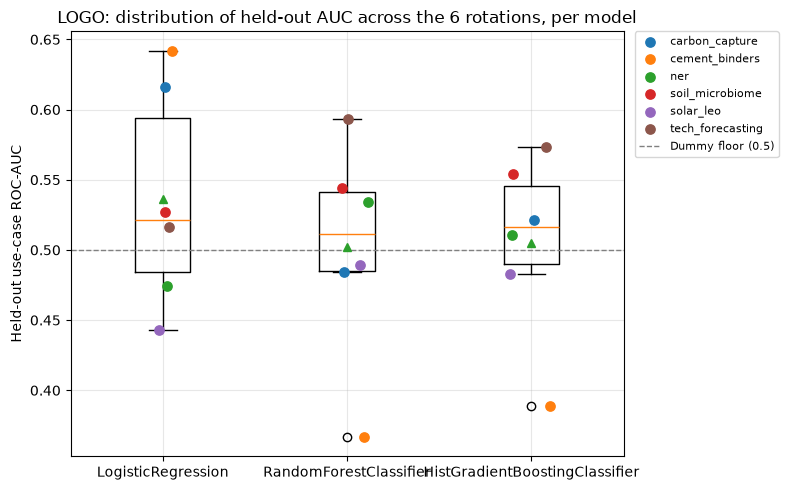

In [9]:
color_map = dict(zip(USE_CASES, plt.cm.tab10.colors))
models_order = ["LogisticRegression", "RandomForestClassifier", "HistGradientBoostingClassifier"]

fig, ax = plt.subplots(figsize=(8, 5))
box_data = [logo_results.loc[logo_results["model"] == m, "holdout_auc"].to_numpy() for m in models_order]
ax.boxplot(box_data, showmeans=True)
ax.set_xticks(range(1, len(models_order) + 1))
ax.set_xticklabels(models_order)

rng = np.random.RandomState(0)
seen = set()
for i, m in enumerate(models_order, start=1):
    sub = logo_results[logo_results["model"] == m]
    for _, row in sub.iterrows():
        uc = row["holdout_use_case"]
        label = uc if uc not in seen else None
        seen.add(uc)
        ax.scatter(i + rng.uniform(-0.12, 0.12), row["holdout_auc"], color=color_map[uc], label=label, zorder=3, s=45)

ax.axhline(0.5, color="grey", linestyle="--", linewidth=1, label="Dummy floor (0.5)")
ax.set_ylabel("Held-out use-case ROC-AUC")
ax.set_title("LOGO: distribution of held-out AUC across the 6 rotations, per model")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), fontsize=8, borderaxespad=0)
plt.tight_layout()
plt.show()


### 3.2 Train → validation → holdout: where does each model's score actually come from?

The boxplot above shows the *holdout* stage's spread across the 6 rotations. This section
adds the other two stages (§3.1) so the drop can be decomposed into two separate,
independently-diagnosable problems:

- **Train → validation** (`overfit_gap_auc`): is the model overfitting to its own training
  use cases, before a new use case even enters the picture?
- **Validation → holdout** (`auc_gap`): given how well the model cross-validates on the use
  cases it was trained on, how much of that further evaporates on a genuinely new one?

Plotted for ROC-AUC, Recall, and F2 (`beta=2`) side by side — mean ± std across the 6
rotations, real candidates only (the `DummyClassifier` floor stays flat at ~0.5/0/0 by
construction and would just compress the y-axis).


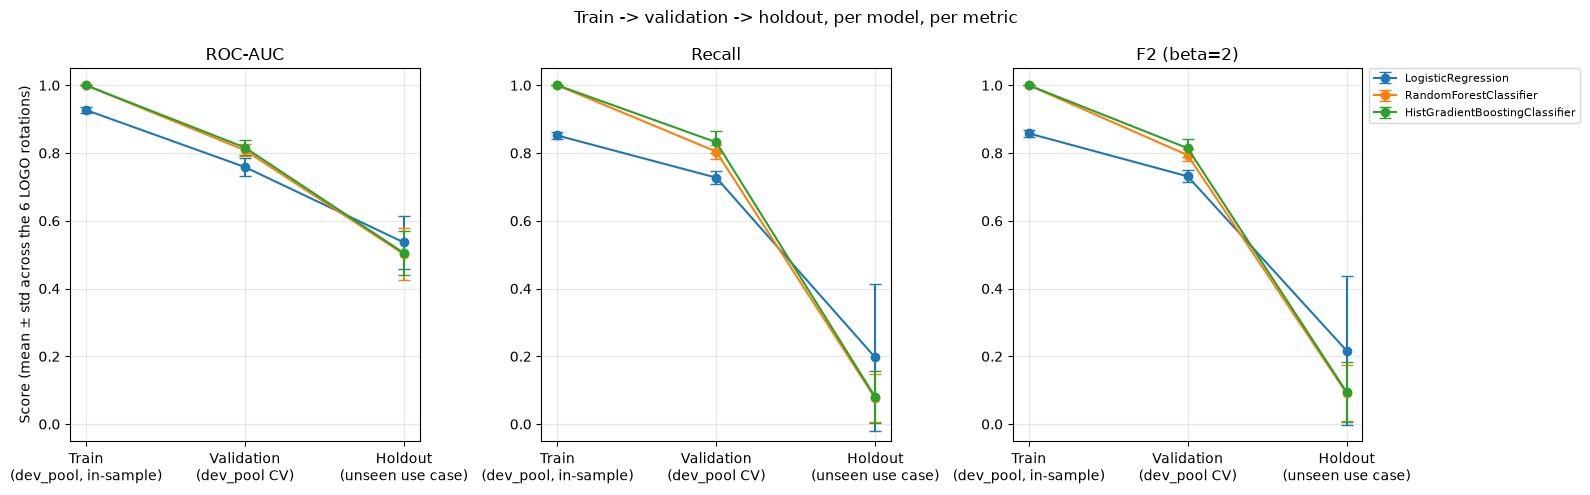

In [10]:
real_models = ["LogisticRegression", "RandomForestClassifier", "HistGradientBoostingClassifier"]
stage_cols = {
    "ROC-AUC": ("train_auc", "in_distribution_auc", "holdout_auc"),
    "Recall": ("train_recall", "in_distribution_recall", "holdout_recall"),
    "F2 (beta=2)": ("train_f2", "in_distribution_f2", "holdout_f2"),
}
stage_labels = ["Train\n(dev_pool, in-sample)", "Validation\n(dev_pool CV)", "Holdout\n(unseen use case)"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True)
for ax, (metric_name, (train_col, val_col, hold_col)) in zip(axes, stage_cols.items()):
    for m in real_models:
        sub = logo_results[logo_results["model"] == m]
        means = [sub[train_col].mean(), sub[val_col].mean(), sub[hold_col].mean()]
        stds = [sub[train_col].std(), sub[val_col].std(), sub[hold_col].std()]
        ax.errorbar(range(3), means, yerr=stds, marker="o", capsize=4, label=m)
    ax.set_xticks(range(3))
    ax.set_xticklabels(stage_labels)
    ax.set_title(metric_name)
    ax.set_ylim(-0.05, 1.05)

axes[0].set_ylabel("Score (mean ± std across the 6 LOGO rotations)")
axes[-1].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), fontsize=8, borderaxespad=0)
fig.suptitle("Train -> validation -> holdout, per model, per metric")
plt.tight_layout()
plt.show()


**Hard finding — the domain-shift gap (validation → holdout) is larger than the overfitting
gap (train → validation), for all three models, consistently across the 6 rotations.**
Every real candidate's `train_auc` is 0.93–1.00 (`RandomForestClassifier` and
`HistGradientBoostingClassifier` hit exactly **1.000, std 0.000, in every single rotation** —
these default-hyperparameter tree ensembles memorize their training rows completely).
`overfit_gap_auc` (train → validation) averages 0.168–0.192 across the three models — real,
but the smaller of the two gaps. `auc_gap` (validation → holdout) averages 0.222–0.311 —
consistently the bigger drop. **Concretely: of the roughly 0.40–0.50 total point collapse from
train to holdout, only about 35–40% is explained by ordinary overfitting to the training use
cases; the majority (60–65%) is the domain-shift problem LOGO was built to measure.** This
matters for what to fix first — reducing tree depth / adding regularization would close some
of the smaller gap, but the bigger problem needs a different feature/model approach
(`reports/wf_ensemble_report.md` §3, §6), not just less overfitting.

**Hard finding — Recall and F2 collapse far more violently than ROC-AUC, and this is exactly
what AUC alone was hiding.** Mean holdout Recall: `LogisticRegression` 0.197 (± a huge 0.217 —
one rotation, `cement_binders` at 0.612, is propping up the average; the other five sit at
0.01–0.14), `RandomForestClassifier` 0.076, `HistGradientBoostingClassifier` 0.080 — down from
72–83% **in-distribution** recall for all three. At the classifier's default 0.5 threshold, a
genuinely new use case sees roughly **8–20% of true positives caught**, not the 70–80%
in-distribution numbers §13-style tables would suggest. ROC-AUC (0.50–0.54 mean) already read
as "barely better than chance," but it's threshold-independent and can look almost survivable
next to this: Recall/F2 show what actually happens at the threshold a deployed system would
use, and it's much worse. This is the clearest evidence in this notebook that a fixed 0.5
cutoff, tuned to the training use cases' own class balance, is not a decision you can carry
into a new one without recalibration — `reports/wf_ensemble_report.md` §4's calibration-only
step for new use cases is directly this fix.


## 4. Interpretation

**Hard finding — the collapse is general, not `tech_forecasting`-specific.** Every real
candidate's mean held-out AUC across all 6 rotations lands in a narrow 0.50–0.54 band
(`HistGradientBoostingClassifier` 0.505 ± 0.065, `RandomForestClassifier` 0.502 ± 0.077,
`LogisticRegression` 0.536 ± 0.078) — essentially indistinguishable from the 0.500 dummy floor
once averaged over all 6 use cases, not just the one originally tested. `wf_fold_pca_test.ipynb`
/ `sf_eda_v2.ipynb` §14's single-holdout check picked `tech_forecasting` specifically because it
looked like the hardest, most topically distant case — and by this notebook's numbers, it
wasn't: `RandomForestClassifier` (0.593) and `HistGradientBoostingClassifier` (0.573) both score
*highest* on `tech_forecasting` of all 6 rotations (see `pivot_holdout`). The original finding
wasn't wrong, but its framing — "this one unusual use case breaks the model" — doesn't survive
contact with the other five. The real finding is **"none of these three candidates generalize
to *any* new use case,"** which resolves the two hypotheses posed in this notebook's intro in
favour of hypothesis 1, and points at a more urgent fix (a materially different feature/model
approach, `reports/wf_ensemble_report.md` §3 and §6) than a narrower topical-similarity guardrail.

**Hard finding — two rotations put both tree models *below* the dummy floor.** `cement_binders`
(`RandomForestClassifier` 0.367, `HistGradientBoostingClassifier` 0.389) and, more mildly,
`carbon_capture` (`RandomForestClassifier` 0.484) and `solar_leo`
(`HistGradientBoostingClassifier` 0.483) score *worse* than always predicting the majority
class. A single holdout could never surface this, because the one use case actually tried
(`tech_forecasting`) happened to be one where both tree models still cleared 0.5. This is the
sharpest evidence in this notebook that deploying either tree baseline on a genuinely new use
case without recalibration carries real downside risk, not just "less upside than hoped."

**Hard finding — the in-distribution model ranking does not survive, and this time it isn't
fold noise.** In-distribution, `sf_eda_v2.ipynb` §13 ranked `HistGradientBoostingClassifier`
(0.816 here) minutely ahead of `RandomForestClassifier` (0.808), both comfortably ahead of
`LogisticRegression` (0.759). Averaged across all 6 LOGO rotations, that ranking flips:
`LogisticRegression` (mean holdout AUC 0.536) beats both tree models (0.505, 0.502). This isn't
one lucky fold — `LogisticRegression` wins outright on `carbon_capture` (0.616) and
`cement_binders` (0.642), by 0.13–0.28 AUC, enough to move the average even though it loses
narrowly on the other four rotations. **Judgement call:** don't read this as "always ship the
linear model" — `LogisticRegression`'s own std across rotations (0.078) is the widest of the
three, so it isn't a *uniformly* better generalizer, it's a *less catastrophically bad* one on
2 of 6 use cases. Whether "higher average, occasionally much better" beats "lower average,
never below-floor" is a product call, not a purely statistical one.

**Hard finding — `wss_at_95` confirms none of these candidates would help a human screener on a
new use case.** Mean `wss_at_95` across rotations: 0.031 (`LogisticRegression`), 0.005
(`HistGradientBoostingClassifier`), 0.000 (`RandomForestClassifier`) — essentially zero
screening-workload reduction beyond chance, consistently, not just on `tech_forecasting`.

**On the leakage check (§1):** only `ner` and `tech_forecasting` picked up any cross-use-case
duplicate rows (4 each, ≈1.3–1.5% of their holdout sets) — too small to be driving the pattern
above, but still worth fixing before trusting either of those two rotations to the third
decimal place.


## 5. What this notebook does not settle

- **Model/feature choices are unchanged.** This is a fold-design comparison against
  `sf_eda_v2.ipynb` §13's exact candidates and features, on purpose — it answers "how should
  we evaluate," not "what should we build." `reports/wf_ensemble_report.md` §3's metadata-only
  arm and richer feature set are a separate, follow-on question.
- **No genuinely external check yet.** All 6 rotations are still drawn from this repo's own
  6 use cases, produced by the same upstream pipeline. `reports/wf_ensemble_report.md` §1
  already flags `uc1` and the public SYNERGY benchmark as the real "touched once, at the end"
  final test — LOGO is a much better *validation* scheme than a single holdout, but it is not
  a substitute for that external check.
- **Hyperparameters are fixed defaults, not tuned per rotation.** A fully nested design would
  tune each candidate's hyperparameters inside the inner loop, separately for each of the 6
  outer rotations, per `reports/wf_ensemble_report.md` §5's "nested CV always" recommendation.
  This notebook keeps hyperparameters fixed to isolate the fold-structure question from a
  tuning question — worth revisiting once a specific architecture is being finalized rather
  than compared.
- **The cross-use-case duplicate-title leakage (§1) is flagged, not fixed.** The right place
  to fix it is `combine_use_cases.ipynb`'s data pipeline, not a downstream modelling notebook.
